# 05_01_4 · Stacking Ensemble — selección del modelo de producción

Único dueño de `stacking_best`. Construye y compara las tres versiones del ensemble:

| Versión | Base learners | Procedencia |
|---|---|---|
| v1 | LGBM afinado + XGB + RF baseline | este notebook |
| v2 | LGBM afinado + **RF afinado** | `rf_tuned` de 05_01_2 |
| v3 | v2 + **SVM afinado** (opcional) | `svm_tuned` de 05_01_3 |

**Objetivo:** combinar LightGBM, XGBoost y Random Forest en un ensemble de stacking
que supere al mejor modelo individual.

### ¿Por qué stacking y no averaging?
- **Averaging**: simplemente promediar las probabilidades de los modelos → fácil pero subóptimo
- **Stacking**: un meta-modelo aprende *cómo combinar* las predicciones de los base learners
  → puede aprender que "cuando LGBM y RF coinciden pero XGB discrepa, confiar en la mayoría"

```
Nivel 0 (base learners)          Nivel 1 (meta-modelo)
──────────────────────           ─────────────────────
LightGBM  ──┐
XGBoost   ──┼─→  probabilidades  →  LogisticRegression  →  predicción final
RandomForest┘
```

### ¿Por qué Regresión Logística como meta-modelo?
- Simple, regularizada, interpretable (sus coeficientes son el "peso" de cada base learner)
- No sobreajusta con solo 3 features de entrada (las 3 probabilidades)
- Con `class_weight='balanced'` mantiene el sesgo hacia la clase fallo

### Clave técnica: out-of-fold predictions
`StackingClassifier` genera las predicciones de nivel 0 mediante cross-validation:
cada base learner predice sobre datos que NO vio en entrenamiento.
Esto evita que el meta-modelo aprenda de predicciones "trampa" (overfitted al train).

In [1]:
import sys; sys.path.insert(0, '../../src')
import pickle
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, f1_score,
    precision_score, recall_score
)
from utils import eval_threshold, LGBM_BEST_PARAMS   # compartidos en src/utils.py

with open('../../data/processed/splits.pkl', 'rb') as f:
    splits = pickle.load(f)
with open('../../models/models.pkl', 'rb') as f:
    models = pickle.load(f)

X_train, X_test, y_train, y_test = splits['ai4i']
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print('Train:', X_train.shape, '| Fallos train:', y_train.sum())
print('Test: ', X_test.shape,  '| Fallos test: ', y_test.sum())


Train: (8000, 10) | Fallos train: 271
Test:  (2000, 10) | Fallos test:  68


## 1. Stacking v1 — LGBM afinado + XGB + RF baseline

Usamos **instancias nuevas** de cada modelo (no los modelos guardados en pkl).

**¿Por qué instancias nuevas?**
`StackingClassifier` reentrena internamente cada base learner con cross-val out-of-fold.
Si usáramos los modelos ya entrenados, las predicciones de nivel 0 serían "trampa"
(generadas con datos que el modelo ya vio) → el meta-modelo aprendería de señal espuria.

Los hiperparámetros son los mejores encontrados en notebooks anteriores:
- LGBM: los del RandomizedSearch (notebook 05)
- XGBoost: parámetros por defecto con `scale_pos_weight`
- RF: 200 árboles con `class_weight='balanced'` (se afinará en notebook 07)

In [2]:
# Mejores parámetros de cada modelo (de notebooks anteriores)
lgbm_best = LGBMClassifier(**LGBM_BEST_PARAMS)

xgb_best = XGBClassifier(
    scale_pos_weight=scale_pos, n_estimators=200,
    random_state=42, eval_metric='logloss', verbosity=0
)

rf_best = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=42, n_jobs=-1
)

base_learners = [
    ('lgbm', lgbm_best),
    ('xgb',  xgb_best),
    ('rf',   rf_best),
]

print('Base learners definidos:')
for name, _ in base_learners:
    print(f'  · {name}')


Base learners definidos:
  · lgbm
  · xgb
  · rf


### 1.1 Entrenar v1


In [3]:
cv_stack = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(class_weight='balanced',
                                       max_iter=1000, random_state=42),
    stack_method='predict_proba',   # pasar probabilidades al meta-modelo
    cv=cv_stack,
    passthrough=False,              # solo probabilidades, no features originales
    n_jobs=-1
)

print('Entrenando stack (esto tarda ~1-2 min)...')
stack.fit(X_train, y_train)
print('Listo.')


Entrenando stack (esto tarda ~1-2 min)...
Listo.


### 1.2 Umbral y evaluación (v1)


In [4]:
y_prob_stack = stack.predict_proba(X_test)[:, 1]

# Umbral óptimo: máximo F1 con Recall >= 0.85
prec_s, rec_s, thr_s = precision_recall_curve(y_test, y_prob_stack)
f1_s = 2 * prec_s[:-1] * rec_s[:-1] / (prec_s[:-1] + rec_s[:-1] + 1e-9)
mask_s = rec_s[:-1] >= 0.85
idx_s = np.argmax(f1_s * mask_s) if mask_s.any() else np.argmax(f1_s)
thr_best = thr_s[idx_s]

y_pred_stack = (y_prob_stack >= thr_best).astype(int)

print(f'=== Stacking — umbral {thr_best:.4f} ===')
print(classification_report(y_test, y_pred_stack, target_names=['Normal', 'Fallo']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_stack):.4f}')


=== Stacking — umbral 0.9657 ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1932
       Fallo       0.91      0.85      0.88        68

    accuracy                           0.99      2000
   macro avg       0.95      0.92      0.94      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9836


## 2. Comparativa con los modelos individuales


In [5]:
try:
    comparativa = {
        'Logistic Regression': eval_threshold(y_test, models['lr'].predict_proba(X_test)[:, 1]),
        'Random Forest':       eval_threshold(y_test, models['rf'].predict_proba(X_test)[:, 1]),
        'XGBoost':             eval_threshold(y_test, models['xgb'].predict_proba(X_test)[:, 1]),
        'LightGBM (tuned)':    eval_threshold(y_test, models['lgbm_tuned'].predict_proba(X_test)[:, 1]),
        'Stacking':            eval_threshold(y_test, y_prob_stack),
    }
    df_comp = pd.DataFrame(comparativa).T
    print(df_comp.sort_values('F1', ascending=False).to_string())
except KeyError as e:
    print(f'Comparativa con lgbm_tuned omitida: {e} no disponible')


                     Precision  Recall      F1  ROC-AUC  Umbral
Stacking                0.9062  0.8529  0.8788   0.9836  0.9657
LightGBM (tuned)        0.8406  0.8529  0.8467   0.9802  0.7390
XGBoost                 0.7945  0.8529  0.8227   0.9800  0.1649
Random Forest           0.6556  0.8676  0.7468   0.9797  0.1500
Logistic Regression     0.1940  0.8529  0.3161   0.9378  0.5370


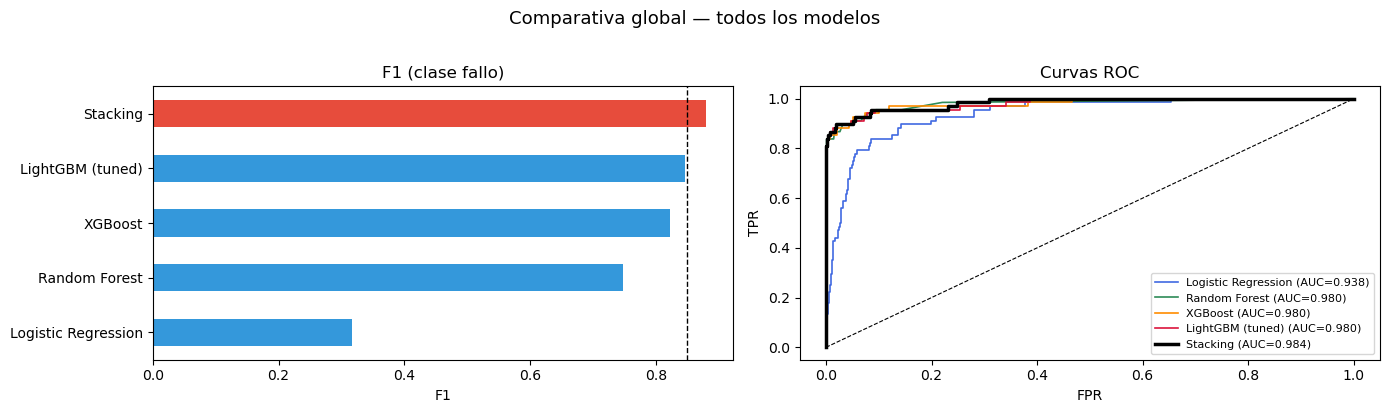

In [6]:
if 'df_comp' in dir():
    # Gráfico comparativa
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Barras F1 / AUC
    df_plot = df_comp[['F1', 'ROC-AUC']].sort_values('F1')
    colors = ['#e74c3c' if i == df_plot.index.get_loc('Stacking') else '#3498db'
              for i in range(len(df_plot))]
    df_plot['F1'].plot(kind='barh', ax=axes[0], color=[
        '#e74c3c' if i == 'Stacking' else '#3498db' for i in df_plot.index])
    axes[0].axvline(0.85, color='black', ls='--', lw=1)
    axes[0].set_title('F1 (clase fallo)')
    axes[0].set_xlabel('F1')
    
    # Curvas ROC
    ax = axes[1]
    palette = {
        'Logistic Regression': 'royalblue',
        'Random Forest':       'seagreen',
        'XGBoost':             'darkorange',
        'LightGBM (tuned)':   'crimson',
        'Stacking':            'black',
    }
    for name, row in comparativa.items():
        m_key = {'Logistic Regression': 'lr', 'Random Forest': 'rf',
                 'XGBoost': 'xgb', 'LightGBM (tuned)': 'lgbm_tuned'}.get(name)
        if m_key:
            yp = models[m_key].predict_proba(X_test)[:, 1]
        else:
            yp = y_prob_stack
        fpr, tpr, _ = roc_curve(y_test, yp)
        lw = 2.5 if name == 'Stacking' else 1.2
        ax.plot(fpr, tpr, color=palette[name], lw=lw,
                label=f"{name} (AUC={row['ROC-AUC']:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title('Curvas ROC')
    ax.legend(fontsize=8)
    
    plt.suptitle('Comparativa global — todos los modelos', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('df_comp no disponible (lgbm_tuned ausente) — omitiendo gráfico comparativa')

## 3. ¿Qué aprende el meta-modelo? (v1)

Los coeficientes de la Regresión Logística muestran el peso que da a cada base learner.


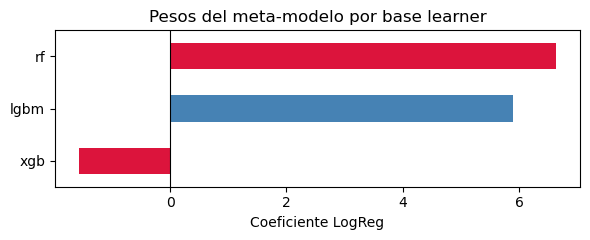

Pesos (prob fallo):
rf      6.6386
lgbm    5.8938
xgb    -1.5723


In [7]:
meta = stack.final_estimator_
n_coef = meta.coef_[0].shape[0]
# sklearn >= 1.1 pasa solo prob(clase=1) al meta-modelo → 1 columna por estimador
if n_coef == len(base_learners):
    coef_names = [name for name, _ in base_learners]
else:
    coef_names = [f'{name}_p{c}' for name, _ in base_learners for c in [0, 1]]

coef_df = pd.Series(meta.coef_[0], index=coef_names)

fig, ax = plt.subplots(figsize=(6, 2.5))
colors = ['crimson' if v > 0 else 'steelblue' for v in coef_df.values]
coef_df.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Pesos del meta-modelo por base learner')
ax.set_xlabel('Coeficiente LogReg')
plt.tight_layout()
plt.show()

print('Pesos (prob fallo):')
print(coef_df.sort_values(ascending=False).round(4).to_string())


### 3.1 Diversidad de los base learners

El stacking es efectivo solo cuando los modelos cometen **errores en observaciones distintas**.
Si LGBM, XGBoost y RF fallaran siempre en los mismos casos, el ensemble no aportaría nada respecto al mejor modelo individual.

Analizamos:
1. **Correlación de probabilidades** entre base learners — baja correlación = más diversidad
2. **Solapamiento de falsos negativos** — cuántos FN comparten los tres modelos

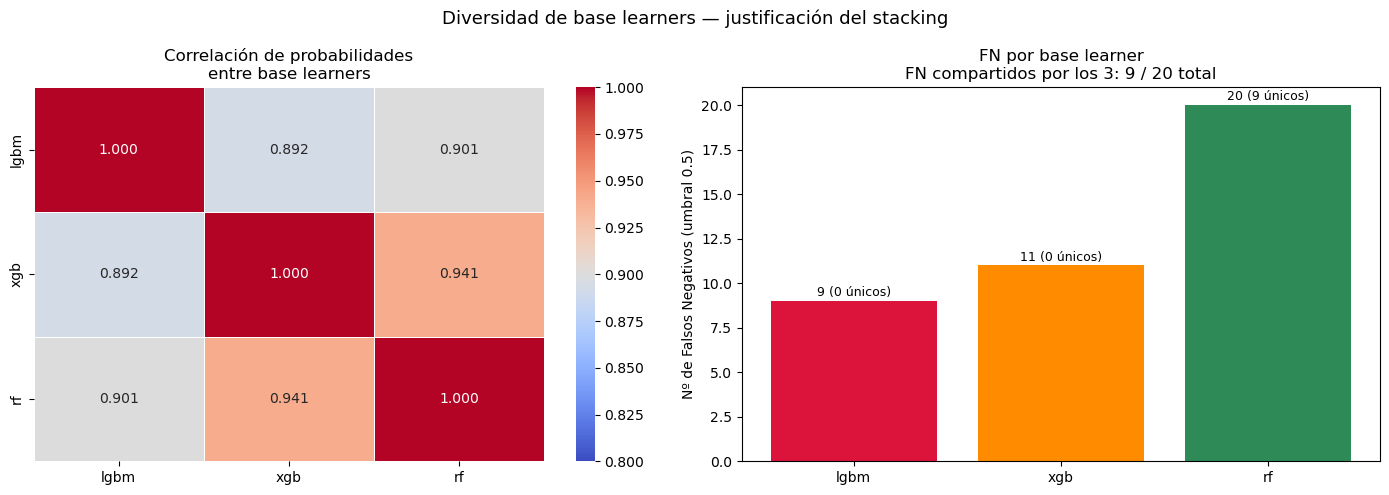

FN únicos (no vistos por los otros dos modelos):
  lgbm: 0 FN exclusivos
  xgb: 0 FN exclusivos
  rf: 9 FN exclusivos
FN compartidos por los 3: 9

→ Correlación alta en probabilidades pero FN distintos = el meta-modelo
  puede aprender a combinar los votos de forma complementaria.


In [8]:
# Probabilidades de cada base learner entrenado dentro del stacking (out-of-fold ya usadas)
# Para test usamos los modelos entrenados con todos los datos de train
probs_bl = {
    name: est.predict_proba(X_test)[:, 1]
    for name, est in stack.named_estimators_.items()
}

# ── Correlación de probabilidades entre base learners ─────────────────────────
probs_df = pd.DataFrame(probs_bl)
corr = probs_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=axes[0],
            vmin=0.8, vmax=1.0, linewidths=0.5)
axes[0].set_title('Correlación de probabilidades\nentre base learners')

# ── Solapamiento de falsos negativos (umbral 0.5 para comparar individualmente) ─
fn_sets = {}
for name, prob in probs_bl.items():
    y_pred_bl = (prob >= 0.5).astype(int)
    fn_sets[name] = set(np.where((y_test == 1) & (y_pred_bl == 0))[0])

fn_counts = {name: len(s) for name, s in fn_sets.items()}
names_bl  = list(fn_sets.keys())

only_unique = {}
for name in names_bl:
    otros = set().union(*[fn_sets[n] for n in names_bl if n != name])
    only_unique[name] = len(fn_sets[name] - otros)

shared_all  = len(fn_sets[names_bl[0]] & fn_sets[names_bl[1]] & fn_sets[names_bl[2]])
total_union = len(fn_sets[names_bl[0]] | fn_sets[names_bl[1]] | fn_sets[names_bl[2]])

ax = axes[1]
bars = ax.bar(names_bl, [fn_counts[n] for n in names_bl],
              color=['crimson', 'darkorange', 'seagreen'])
ax.set_ylabel('Nº de Falsos Negativos (umbral 0.5)')
ax.set_title(f'FN por base learner\nFN compartidos por los 3: {shared_all} / {total_union} total')
for bar, name in zip(bars, names_bl):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{fn_counts[name]} ({only_unique[name]} únicos)",
            ha='center', va='bottom', fontsize=9)

plt.suptitle('Diversidad de base learners — justificación del stacking', fontsize=13)
plt.tight_layout()
plt.show()

print(f'FN únicos (no vistos por los otros dos modelos):')
for name in names_bl:
    print(f'  {name}: {only_unique[name]} FN exclusivos')
print(f'FN compartidos por los 3: {shared_all}')
print(f'\n→ Correlación alta en probabilidades pero FN distintos = el meta-modelo')
print('  puede aprender a combinar los votos de forma complementaria.')

### 3.2 Matrices de confusión — LightGBM vs Stacking v1


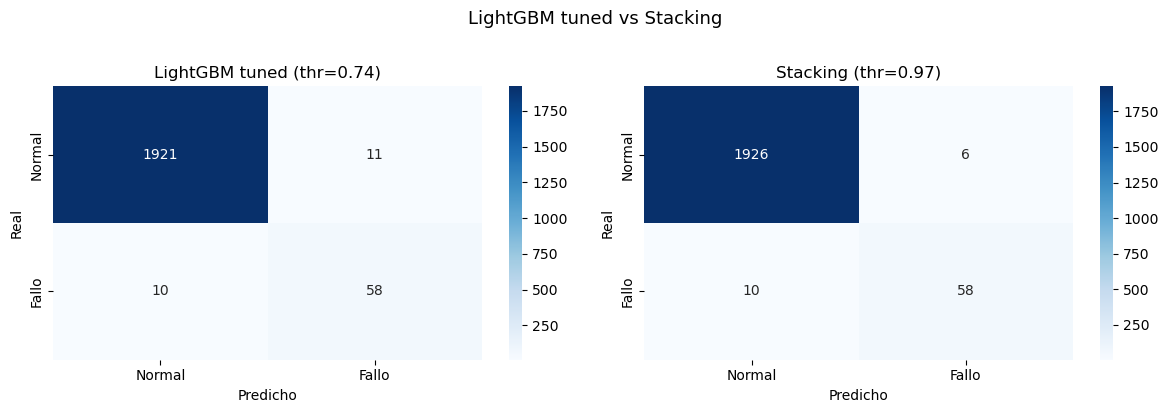

In [9]:
try:
    y_prob_lgbm = models['lgbm_tuned'].predict_proba(X_test)[:, 1]
    thr_lgbm = models['lgbm_threshold']
    y_pred_lgbm = (y_prob_lgbm >= thr_lgbm).astype(int)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, preds, title in [
        (axes[0], y_pred_lgbm,  f'LightGBM tuned (thr={thr_lgbm:.2f})'),
        (axes[1], y_pred_stack, f'Stacking (thr={thr_best:.2f})'),
    ]:
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Normal', 'Fallo'],
                    yticklabels=['Normal', 'Fallo'])
        ax.set_title(title)
        ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
    
    plt.suptitle('LightGBM tuned vs Stacking', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
except KeyError as e:
    print(f'Comparativa con lgbm_tuned omitida: {e} no disponible')

## 4. Stacking v2 — LGBM + RF afinado

---
**Decisión de diseño** — ¿por qué este stacking no incluye XGBoost?

El stacking del notebook anterior (08_Stacking) usaba **LGBM + XGBoost + RF**. Sin embargo, al analizar los pesos del meta-modelo, XGBoost recibía el coeficiente más bajo — era el base learner que menos información nueva aportaba al ensemble.

La causa es estructural: **LGBM y XGBoost pertenecen a la misma familia** — ambos son gradient boosting secuencial con árboles. Aprenden mediante el mismo principio (minimizar el gradiente del error en cada paso), lo que hace que sus predicciones estén altamente correlacionadas. Cuando dos modelos fallan en los mismos casos, el stacking no gana nada al incluirlos a los dos.

**Decisión:** reemplazar XGBoost por un **RF bien afinado** como segundo base learner.
- **RF** es bagging: árboles entrenados en paralelo e independientemente sobre bootstraps distintos
- **LGBM** es boosting: árboles secuenciales donde cada uno corrige los errores del anterior
- Son paradigmas opuestos → mayor diversidad de errores → el meta-modelo tiene señal complementaria real

Este es el motivo por el que LGBM + RF (2 modelos) supera a LGBM + XGB + RF (3 modelos).

---

In [10]:
# rf_tuned viene de 05_01_2_RF_AI4I — prerequisito de este notebook
if models.get('rf_tuned') is None:
    raise KeyError('rf_tuned no está en models.pkl — ejecuta antes 05_01_2_RF_AI4I')

stack_v2 = StackingClassifier(
    estimators=[('lgbm', LGBMClassifier(**LGBM_BEST_PARAMS)),
                ('rf',   clone(models['rf_tuned']))],
    final_estimator=LogisticRegression(class_weight='balanced',
                                       max_iter=1000, random_state=42),
    stack_method='predict_proba', cv=cv_stack, passthrough=False, n_jobs=-1,
)
print('Entrenando stacking v2 (LGBM + RF afinado)...')
stack_v2.fit(X_train, y_train)
print('Listo.')

y_prob_v2 = stack_v2.predict_proba(X_test)[:, 1]
res_v2 = eval_threshold(y_test, y_prob_v2)
print('v2:', res_v2)


Entrenando stacking v2 (LGBM + RF afinado)...
Listo.
v2: {'Precision': 0.9206, 'Recall': 0.8529, 'F1': 0.8855, 'ROC-AUC': 0.9823, 'Umbral': 0.9766}


## 5. Stacking v3 — + SVM afinado (experimento opcional)

¿Aporta diversidad un tercer base learner con geometría distinta (kernel RBF)?
Esta sección requiere `svm_tuned` (notebook `05_01_3_SVM_AI4I`, Optuna lento).
Si no está, **se omite con aviso** — es un experimento opcional que históricamente
se descartó, no un prerequisito del modelo de producción.


In [11]:
svm_tuned = models.get('svm_tuned')
if svm_tuned is None:
    print('⚠ svm_tuned no está en models.pkl — sección v3 OMITIDA.')
    print('  Para reproducirla: ejecuta 05_01_3_SVM_AI4I y re-ejecuta este notebook.')
    stack_v3, res_v3 = None, None
else:
    stack_v3 = StackingClassifier(
        estimators=[('lgbm', LGBMClassifier(**LGBM_BEST_PARAMS)),
                    ('rf',   clone(models['rf_tuned'])),
                    ('svm',  clone(svm_tuned))],
        final_estimator=LogisticRegression(class_weight='balanced',
                                           max_iter=1000, random_state=42),
        stack_method='predict_proba', cv=cv_stack, passthrough=False, n_jobs=-1,
    )
    print('Entrenando stacking v3 (LGBM + RF + SVM)...')
    stack_v3.fit(X_train, y_train)
    y_prob_v3 = stack_v3.predict_proba(X_test)[:, 1]
    res_v3 = eval_threshold(y_test, y_prob_v3)
    print('v3:', res_v3)


Entrenando stacking v3 (LGBM + RF + SVM)...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   1.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   0.7s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   0.7s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   0.7s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   0.7s
[Pipeline] ............... (step 2 of 2) Processing svc, total=   0.7s
v3: {'Precision': 0.9062, 'Recall': 0.8529, 'F1': 0.8788, 'ROC-AUC': 0.9819, 'Umbral': 0.968}


## 6. Decisión final y guardado

Gana el mayor F1 a umbral óptimo (Recall ≥ 0.85). Este notebook es el **único** que escribe `stacking_best`.


In [12]:
res_v1 = eval_threshold(y_test, y_prob_stack)
candidatos = {'v1 (LGBM+XGB+RF base)': (stack, res_v1),
              'v2 (LGBM+RF afinado)':  (stack_v2, res_v2)}
if res_v3 is not None:
    candidatos['v3 (LGBM+RF+SVM)'] = (stack_v3, res_v3)

tabla = pd.DataFrame({k: v[1] for k, v in candidatos.items()}).T
print(tabla.sort_values('F1', ascending=False).to_string())

best_name = tabla['F1'].idxmax()
best_model, best_res = candidatos[best_name]
print(f'\n→ GANADOR: {best_name} | F1={best_res["F1"]} | umbral={best_res["Umbral"]}')

coef = pd.Series(best_model.final_estimator_.coef_[0],
                 index=[n for n, _ in best_model.estimators])
print('Pesos del meta-modelo:', coef.round(4).to_dict())

# Guardar
import pickle as _pickle
_pkl = '../../models/models.pkl'
with open(_pkl, 'rb') as _f:
    _m = _pickle.load(_f)
_m['stacking']                = stack          # v1, para trazabilidad
_m['stacking_threshold']      = thr_best
_m['stacking_best']           = best_model     # ganador → modelo de producción
_m['stacking_best_threshold'] = best_res['Umbral']
with open(_pkl, 'wb') as _f:
    _pickle.dump(_m, _f)
print('\nGuardados: stacking (v1), stacking_best (ganador) | Total keys:', len(_m))


                       Precision  Recall      F1  ROC-AUC  Umbral
v2 (LGBM+RF afinado)      0.9206  0.8529  0.8855   0.9823  0.9766
v1 (LGBM+XGB+RF base)     0.9062  0.8529  0.8788   0.9836  0.9657
v3 (LGBM+RF+SVM)          0.9062  0.8529  0.8788   0.9819  0.9680

→ GANADOR: v2 (LGBM+RF afinado) | F1=0.8855 | umbral=0.9766
Pesos del meta-modelo: {'lgbm': 3.7104, 'rf': 7.46}

Guardados: stacking (v1), stacking_best (ganador) | Total keys: 20


## 7. Conclusiones

- **v2 (LGBM + RF afinado) es el ensemble de producción**: el RF afinado aporta más
  que el XGBoost baseline de v1 (correlación >0.9 con el LGBM, poca diversidad).
- **v3 (+SVM)** se evaluó históricamente y **no mejoró** — con 8.000 muestras de train
  el meta-modelo no extrae diversidad adicional del kernel RBF.
- `stacking_best` alimenta los experimentos (05_01_5/6/7) y la construcción del
  modelo final (`06_03`, que lo reconstruye desde `utils` para producción).
